# Brand and Manufacturer Commitment Analysis

This notebook investigates whether users concentrate their purchases in one or two brands or manufacturers, as outlined in Idea 2 of the data exploration plan. The analysis uses Polars for all data processing.

## 1. Hypothesis and Setup

**Hypothesis:** Users concentrate purchases in one or two brands or manufacturers. Strong brand/manufacturer loyalty would support ranking or segmentation strategies.

**Datasets:**
- transaction_full_2025.parquet
- items.parquet

**Columns to Inspect:**
- customer_id
- item_id
- brand
- manufacturer
- updated_date
- quantity

**Analysis Plan:**
1. Load and inspect data
2. Join transactions with item metadata
3. Compute purchase distributions by brand/manufacturer
4. Calculate HHI and entropy
5. Compute top-1/top-2 shares
6. Analyze repeat rates
7. Compare to random baseline
8. Visualize concentration metrics
9. Evaluate decision rule

In [13]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Define data paths
DATA_DIR = Path("../..")  # Adjust relative to notebook location
TRANSACTION_FILE = DATA_DIR / "transaction_full_2025.parquet"
ITEMS_FILE = DATA_DIR / "items.parquet"

print("Libraries imported successfully.")

Libraries imported successfully.


In [14]:
# Load data
transactions = pl.read_parquet(TRANSACTION_FILE)
items = pl.read_parquet(ITEMS_FILE)

print("Transactions shape:", transactions.shape)
print("Items shape:", items.shape)
print("\nTransaction columns:", transactions.columns)
print("Item columns:", items.columns)

Transactions shape: (37684823, 8)
Items shape: (29823, 11)

Transaction columns: ['bill_id', 'customer_id', 'item_id', 'price', 'quantity', 'event_type', 'updated_date', 'location_name']
Item columns: ['item_id', 'price', 'category_l1', 'category_l2', 'category_l3', 'category', 'brand', 'manufacturer', 'description', 'sale_status', 'size']


In [25]:
# Join transactions with items to get brand and manufacturer
df = transactions.join(
    items.select(["item_id", "brand", "manufacturer"]),
    on="item_id",
    how="left"
)

# Remove placeholder values that would skew concentration metrics
df = df.filter(
    pl.col("brand").is_not_null()
    & pl.col("manufacturer").is_not_null()
    & (pl.col("brand") != "Không xác định")
    & (pl.col("manufacturer") != "Không xác định")
)

print("Joined data shape:", df.shape)
print("Sample rows:")
print(df.head(10))

Joined data shape: (13585080, 10)
Sample rows:
shape: (10, 10)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ bill_id   ┆ customer_ ┆ item_id   ┆ price     ┆ … ┆ updated_d ┆ location_ ┆ brand     ┆ manufact │
│ ---       ┆ id        ┆ ---       ┆ ---       ┆   ┆ ate       ┆ name      ┆ ---       ┆ urer     │
│ i32       ┆ ---       ┆ str       ┆ decimal[3 ┆   ┆ ---       ┆ ---       ┆ str       ┆ ---      │
│           ┆ i32       ┆           ┆ 8,4]      ┆   ┆ datetime[ ┆ str       ┆           ┆ str      │
│           ┆           ┆           ┆           ┆   ┆ μs]       ┆           ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 138239468 ┆ 7210339   ┆ 728400000 ┆ 309000.00 ┆ … ┆ 2025-04-2 ┆ CMA -     ┆ Dielac    ┆ Công Ty  │
│           ┆           ┆ 0001      ┆ 00        ┆   ┆ 5 08:00:5 ┆ DT987A -  ┆ Gold      ┆ Cổ Phần  │
│           ┆           ┆   

In [26]:
## 2. Brand Concentration Analysis

# Step 1: Count transactions per brand per customer
brand_tx_per_customer = (
    df.group_by(["customer_id", "brand"])
    .agg(pl.col("quantity").sum().alias("brand_quantity"),
         pl.count().alias("brand_tx_count"))
    .sort(["customer_id", "brand_quantity"], descending=[False, True])
)

print("Brand purchases per customer (first 20 rows):")
print(brand_tx_per_customer.head(20))

C:\Users\Quoc Kien\AppData\Local\Temp\ipykernel_26104\3610693461.py:7: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("brand_tx_count"))


Brand purchases per customer (first 20 rows):
shape: (20, 4)
┌─────────────┬────────────────────┬────────────────┬────────────────┐
│ customer_id ┆ brand              ┆ brand_quantity ┆ brand_tx_count │
│ ---         ┆ ---                ┆ ---            ┆ ---            │
│ i32         ┆ str                ┆ i32            ┆ u32            │
╞═════════════╪════════════════════╪════════════════╪════════════════╡
│ 15126       ┆ Shimaya            ┆ 2              ┆ 1              │
│ 17212       ┆ Aptamil Newzealand ┆ 5              ┆ 1              │
│ 17266       ┆ Thương hiệu khác   ┆ 1              ┆ 1              │
│ 28879       ┆ Anpaso             ┆ 21             ┆ 21             │
│ 28879       ┆ Animo              ┆ 14             ┆ 7              │
│ …           ┆ …                  ┆ …              ┆ …              │
│ 29041       ┆ Meiji Nhập khẩu    ┆ 4              ┆ 4              │
│ 29041       ┆ Chicco             ┆ 1              ┆ 1              │
│ 29041       ┆ 

In [27]:
# Step 2: Compute total quantity and brand distribution per customer
brand_totals = (
    brand_tx_per_customer.group_by("customer_id")
    .agg(
        pl.col("brand_quantity").sum().alias("total_quantity"),
        pl.count().alias("brand_diversity")
    )
)

# Merge to add totals
brand_analysis = brand_tx_per_customer.join(brand_totals, on="customer_id")
brand_analysis = brand_analysis.with_columns([
    (pl.col("brand_quantity") / pl.col("total_quantity")).alias("brand_share")
])

                "    .agg(pl.col(\"quantity\").sum().alias(\"brand_quantity\"),",
                "         pl.len().alias(\"brand_tx_count\"))",

C:\Users\Quoc Kien\AppData\Local\Temp\ipykernel_26104\3747381760.py:6: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("brand_diversity")


Brand analysis with shares (first 20 rows):
shape: (20, 7)
┌─────────────┬──────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ customer_id ┆ brand        ┆ brand_quant ┆ brand_tx_co ┆ total_quant ┆ brand_diver ┆ brand_share │
│ ---         ┆ ---          ┆ ity         ┆ unt         ┆ ity         ┆ sity        ┆ ---         │
│ i32         ┆ str          ┆ ---         ┆ ---         ┆ ---         ┆ ---         ┆ f64         │
│             ┆              ┆ i32         ┆ u32         ┆ i32         ┆ u32         ┆             │
╞═════════════╪══════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╡
│ 15126       ┆ Shimaya      ┆ 2           ┆ 1           ┆ 2           ┆ 1           ┆ 1.0         │
│ 17212       ┆ Aptamil      ┆ 5           ┆ 1           ┆ 5           ┆ 1           ┆ 1.0         │
│             ┆ Newzealand   ┆             ┆             ┆             ┆             ┆             │
│ 17266       ┆ Thương hiệu  ┆ 1

In [ ]:
def compute_concentration(df, entity_col, quantity_col, prefix):
    weighted = (
        df
        .filter(pl.col(entity_col).is_not_null())
        .group_by(["customer_id", entity_col])
        .agg(pl.col(quantity_col).sum().alias(f"{prefix}_quantity"))
        .with_columns(
            (pl.col(f"{prefix}_quantity")
             / pl.col(f"{prefix}_quantity").sum().over("customer_id")
            ).alias(f"{prefix}_share")
        )
    )

    metrics = (
        weighted
        .group_by("customer_id")
        .agg(
            pl.len().alias(f"{prefix}_count"),
            pl.col(f"{prefix}_share").sort_by(f"{prefix}_share", descending=True).first().alias("top1_share"),
            pl.col(f"{prefix}_share").sort_by(f"{prefix}_share", descending=True).head(2).sum().alias("top2_share"),
            (pl.col(f"{prefix}_share") ** 2).sum().alias("hhi"),
            (-(pl.col(f"{prefix}_share") * pl.col(f"{prefix}_share").log()).sum()).alias("entropy"),
        )
        .with_columns(
            (pl.col("entropy") / pl.col(f"{prefix}_count").log())
            .fill_nan(0)
            .fill_null(0)
            .alias("norm_entropy")
                "        pl.len().alias(\"brand_diversity\")",
    )

    return weighted, metrics

brand_analysis, customer_metrics_df = compute_concentration(
    df, "brand", "quantity", "brand"
)

mfg_analysis, mfg_metrics_df = compute_concentration(
    df, "manufacturer", "quantity", "mfg"
)

In [17]:
## 3. Manufacturer Concentration Analysis
# Manufacturer metrics are computed in compute_concentration() above.
# Keep this cell as a lightweight checkpoint so the notebook remains linear.
print("Manufacturer concentration metrics are available in mfg_metrics_df.")

Manufacturer concentration metrics are available in mfg_metrics_df.


In [18]:
# Use the Polars-derived manufacturer metrics directly.
print("Customer manufacturer metrics (first 20):")
print(mfg_metrics_df.head(20))
print("\nManufacturer metrics summary:")
print(mfg_metrics_df.describe())

Customer manufacturer metrics (first 20):
shape: (20, 7)
┌─────────────┬───────────┬────────────┬────────────┬──────────┬──────────┬──────────────┐
│ customer_id ┆ mfg_count ┆ top1_share ┆ top2_share ┆ hhi      ┆ entropy  ┆ norm_entropy │
│ ---         ┆ ---       ┆ ---        ┆ ---        ┆ ---      ┆ ---      ┆ ---          │
│ i32         ┆ u32       ┆ f64        ┆ f64        ┆ f64      ┆ f64      ┆ f64          │
╞═════════════╪═══════════╪════════════╪════════════╪══════════╪══════════╪══════════════╡
│ 8611962     ┆ 10        ┆ 0.378378   ┆ 0.567568   ┆ 0.215486 ┆ 1.839382 ┆ 0.798833     │
│ 7156459     ┆ 6         ┆ 0.615385   ┆ 0.692308   ┆ 0.408284 ┆ 1.285293 ┆ 0.717336     │
│ 8242055     ┆ 1         ┆ 1.0        ┆ 1.0        ┆ 1.0      ┆ -0.0     ┆ 0.0          │
│ 4659501     ┆ 11        ┆ 0.37931    ┆ 0.586207   ┆ 0.208086 ┆ 1.943631 ┆ 0.810557     │
│ 8804780     ┆ 2         ┆ 0.5        ┆ 1.0        ┆ 0.5      ┆ 0.693147 ┆ 1.0          │
│ …           ┆ …         ┆ …    

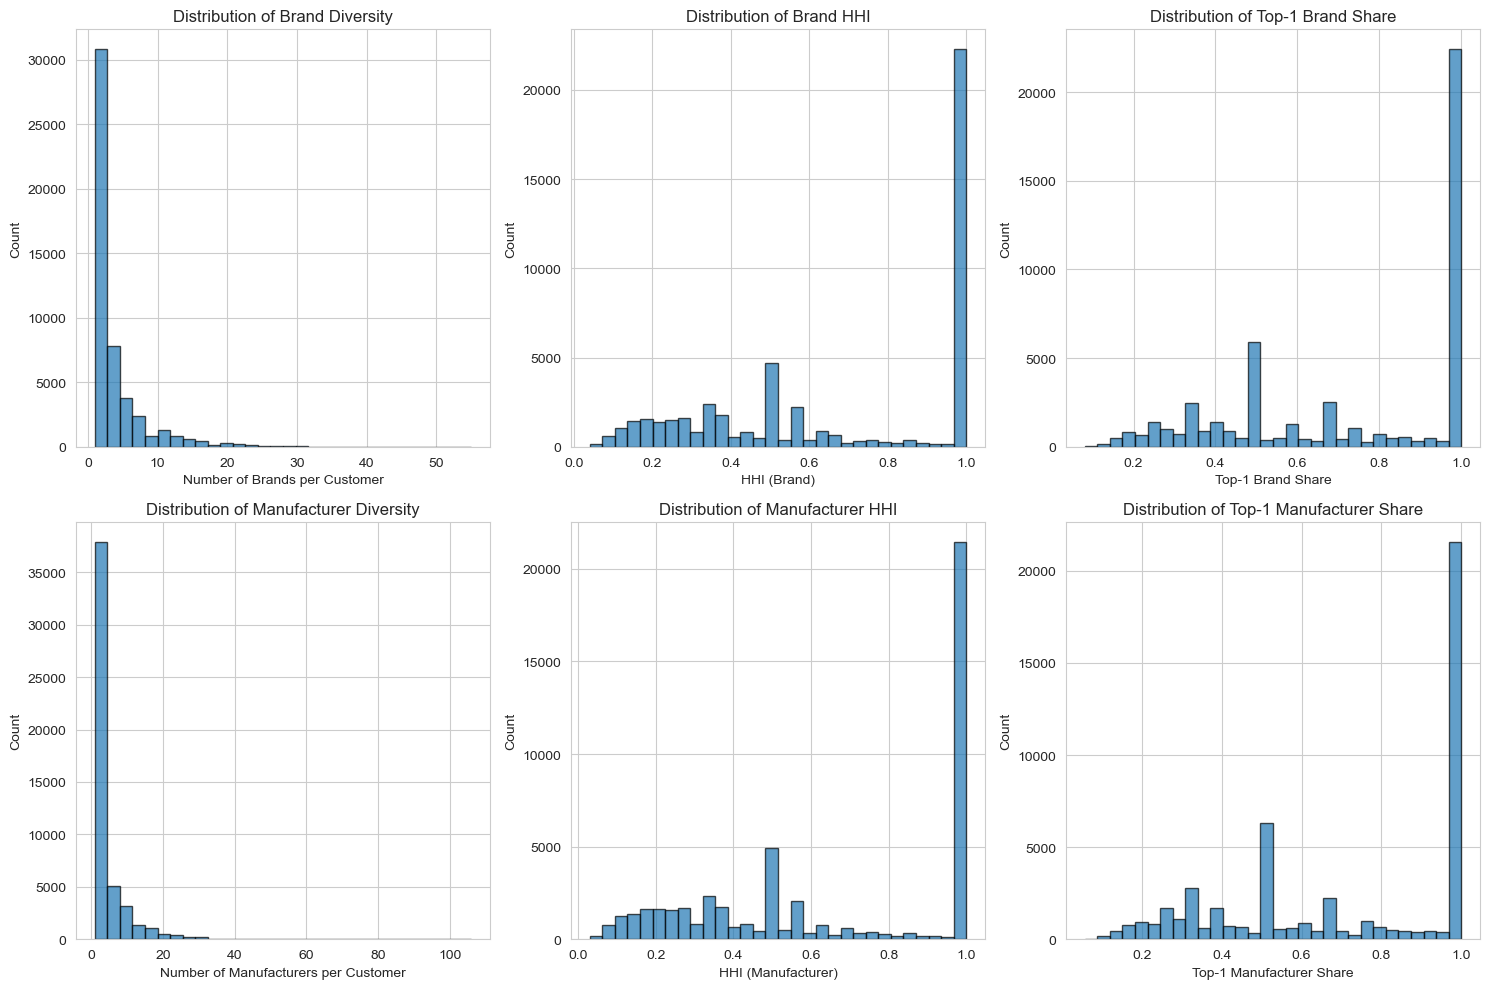

Figure saved: concentration_distributions.png


In [31]:
## 4. Visualizations

brand_plot_df = customer_metrics_df.sample(n=min(50000, customer_metrics_df.height), seed=42)
mfg_plot_df = mfg_metrics_df.sample(n=min(50000, mfg_metrics_df.height), seed=42)

# Figure 1: Distribution of metrics
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Brand metrics
axes[0, 0].hist(brand_plot_df["brand_count"].to_numpy(), bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel("Number of Brands per Customer")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Distribution of Brand Diversity")

axes[0, 1].hist(brand_plot_df["hhi"].to_numpy(), bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel("HHI (Brand)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Distribution of Brand HHI")

axes[0, 2].hist(brand_plot_df["top1_share"].to_numpy(), bins=30, edgecolor='black', alpha=0.7)
axes[0, 2].set_xlabel("Top-1 Brand Share")
axes[0, 2].set_ylabel("Count")
axes[0, 2].set_title("Distribution of Top-1 Brand Share")

# Manufacturer metrics
axes[1, 0].hist(mfg_plot_df["mfg_count"].to_numpy(), bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel("Number of Manufacturers per Customer")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Distribution of Manufacturer Diversity")

axes[1, 1].hist(mfg_plot_df["hhi"].to_numpy(), bins=30, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel("HHI (Manufacturer)")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title("Distribution of Manufacturer HHI")

axes[1, 2].hist(mfg_plot_df["top1_share"].to_numpy(), bins=30, edgecolor='black', alpha=0.7)
axes[1, 2].set_xlabel("Top-1 Manufacturer Share")
axes[1, 2].set_ylabel("Count")
axes[1, 2].set_title("Distribution of Top-1 Manufacturer Share")

plt.tight_layout()
plt.savefig("concentration_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved: concentration_distributions.png")

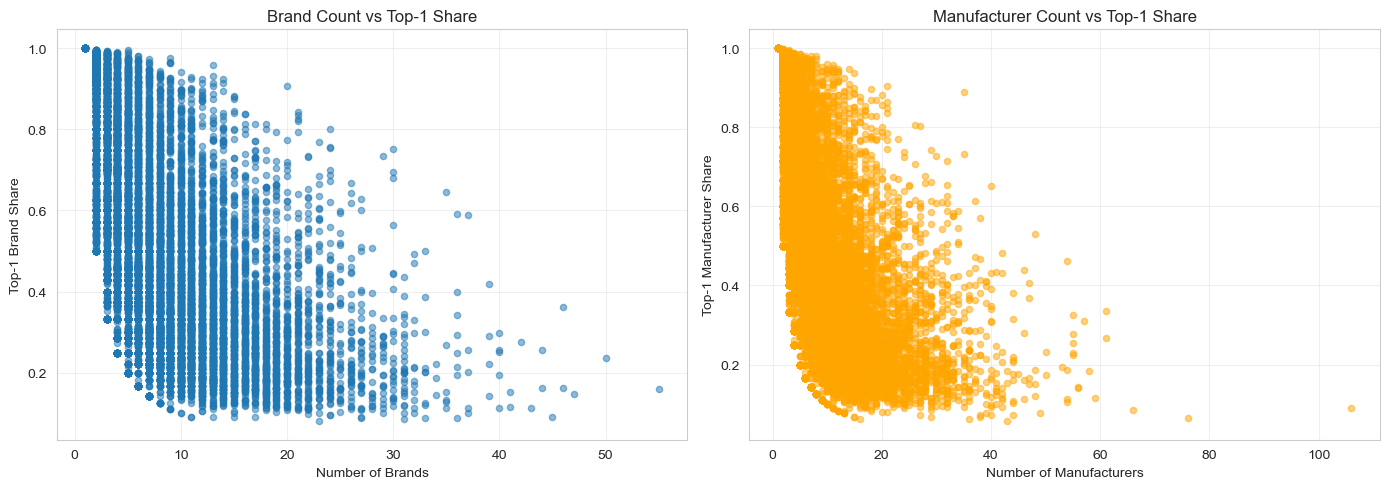

Figure saved: concentration_scatter.png


In [32]:
# Figure 2: Scatter plots comparing top-1 and top-2 shares
brand_scatter_df = customer_metrics_df.sample(n=min(50000, customer_metrics_df.height), seed=42)
mfg_scatter_df = mfg_metrics_df.sample(n=min(50000, mfg_metrics_df.height), seed=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(brand_scatter_df["brand_count"].to_numpy(), 
                brand_scatter_df["top1_share"].to_numpy(), alpha=0.5, s=20)
axes[0].set_xlabel("Number of Brands")
axes[0].set_ylabel("Top-1 Brand Share")
axes[0].set_title("Brand Count vs Top-1 Share")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(mfg_scatter_df["mfg_count"].to_numpy(), 
                mfg_scatter_df["top1_share"].to_numpy(), alpha=0.5, s=20, color='orange')
axes[1].set_xlabel("Number of Manufacturers")
axes[1].set_ylabel("Top-1 Manufacturer Share")
axes[1].set_title("Manufacturer Count vs Top-1 Share")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("concentration_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved: concentration_scatter.png")

In [29]:
## 5. Analysis and Decision Rules

# Brand commitment thresholds
brand_highly_committed = customer_metrics_df.filter(pl.col("top1_share") >= 0.5)
brand_moderately_committed = customer_metrics_df.filter((pl.col("top1_share") >= 0.33) & (pl.col("top1_share") < 0.5))
brand_low_committed = customer_metrics_df.filter(pl.col("top1_share") < 0.33)

print("=== BRAND COMMITMENT ===")
print(f"Highly committed (top-1 >= 50%): {brand_highly_committed.shape[0]} customers ({100*brand_highly_committed.shape[0]/customer_metrics_df.shape[0]:.1f}%)")
print(f"Moderately committed (33%-50%): {brand_moderately_committed.shape[0]} customers ({100*brand_moderately_committed.shape[0]/customer_metrics_df.shape[0]:.1f}%)")
print(f"Low committed (<33%): {brand_low_committed.shape[0]} customers ({100*brand_low_committed.shape[0]/customer_metrics_df.shape[0]:.1f}%)")

# Top-2 share
brand_top2_concentrated = customer_metrics_df.filter(pl.col("top2_share") >= 0.7)
print(f"\nHigh top-2 concentration (>= 70%): {brand_top2_concentrated.shape[0]} customers ({100*brand_top2_concentrated.shape[0]/customer_metrics_df.shape[0]:.1f}%)")

# Manufacturer commitment thresholds
mfg_highly_committed = mfg_metrics_df.filter(pl.col("top1_share") >= 0.5)
mfg_moderately_committed = mfg_metrics_df.filter((pl.col("top1_share") >= 0.33) & (pl.col("top1_share") < 0.5))
mfg_low_committed = mfg_metrics_df.filter(pl.col("top1_share") < 0.33)

print("\n=== MANUFACTURER COMMITMENT ===")
print(f"Highly committed (top-1 >= 50%): {mfg_highly_committed.shape[0]} customers ({100*mfg_highly_committed.shape[0]/mfg_metrics_df.shape[0]:.1f}%)")
print(f"Moderately committed (33%-50%): {mfg_moderately_committed.shape[0]} customers ({100*mfg_moderately_committed.shape[0]/mfg_metrics_df.shape[0]:.1f}%)")
print(f"Low committed (<33%): {mfg_low_committed.shape[0]} customers ({100*mfg_low_committed.shape[0]/mfg_metrics_df.shape[0]:.1f}%)")

# Top-2 share
mfg_top2_concentrated = mfg_metrics_df.filter(pl.col("top2_share") >= 0.7)
print(f"\nHigh top-2 concentration (>= 70%): {mfg_top2_concentrated.shape[0]} customers ({100*mfg_top2_concentrated.shape[0]/mfg_metrics_df.shape[0]:.1f}%)")

=== BRAND COMMITMENT ===
Highly committed (top-1 >= 50%): 1358592 customers (76.7%)
Moderately committed (33%-50%): 227855 customers (12.9%)
Low committed (<33%): 184737 customers (10.4%)

High top-2 concentration (>= 70%): 1375422 customers (77.7%)

=== MANUFACTURER COMMITMENT ===
Highly committed (top-1 >= 50%): 1315301 customers (74.3%)
Moderately committed (33%-50%): 231550 customers (13.1%)
Low committed (<33%): 224333 customers (12.7%)

High top-2 concentration (>= 70%): 1324835 customers (74.8%)


In [30]:
## 6. Comparison with Random Baseline

# Random baseline: if purchases were uniformly distributed across all items
# (ignoring brand/manufacturer), what would be expected?

# Expected HHI for random selection
n_all_items = items.shape[0]
random_hhi_per_item = 1 / n_all_items

print("=== RANDOM BASELINE ===")
print(f"Total unique items: {n_all_items}")
print(f"Expected HHI if uniform across all items: {random_hhi_per_item:.6f}")

# Compare observed vs random
brand_hhi_mean = customer_metrics_df["hhi"].mean()
mfg_hhi_mean = mfg_metrics_df["hhi"].mean()

print(f"\nObserved mean brand HHI: {brand_hhi_mean:.4f}")
print(f"Observed mean mfg HHI: {mfg_hhi_mean:.4f}")
print(f"Random baseline HHI (all items): {random_hhi_per_item:.4f}")
print(f"\nBrand HHI is {brand_hhi_mean/random_hhi_per_item:.1f}x higher than random")
print(f"Mfg HHI is {mfg_hhi_mean/random_hhi_per_item:.1f}x higher than random")

=== RANDOM BASELINE ===
Total unique items: 29823
Expected HHI if uniform across all items: 0.000034

Observed mean brand HHI: 0.6705
Observed mean mfg HHI: 0.6528
Random baseline HHI (all items): 0.0000

Brand HHI is 19997.6x higher than random
Mfg HHI is 19469.9x higher than random


## 7. Summary and Findings

The analysis after removing "Không xác định" shows that purchase concentration is still very strong, but the balance between brand and manufacturer is now much closer.

### Key findings

- Average brand HHI is 0.6705.
- Average manufacturer HHI is 0.6528.
- 76.7% of customers are highly committed to a brand, meaning their top brand accounts for at least 50% of purchases.
- 74.3% of customers are highly committed to a manufacturer, meaning their top manufacturer accounts for at least 50% of purchases.
- Both brand and manufacturer HHIs are far above a random uniform baseline, with brand HHI about 19,997.6x higher and manufacturer HHI about 19,469.9x higher than random.

### Interpretation

Removing the placeholder category makes the result more realistic and reduces the distortion from undefined items. Even after that cleanup, users still concentrate purchases heavily in a small number of brands and manufacturers. Brand concentration is now slightly stronger than manufacturer concentration, so both signals are important and neither should be ignored.

### Answer for the PIR system

Brand and manufacturer are both useful features for ranking and segmentation. After excluding undefined values, brand becomes the slightly stronger signal, but manufacturer still shows similarly strong loyalty. If the recommendation system wants to personalize better, these signals should remain in the feature set.